# Data Understanding & Cleaning

**Importing dependencies and load dataset**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


In [30]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Customer Churn & CLV Prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv')

**Basic Overview of dataset**

In [31]:
print(df.shape)
print(df['Churn'].value_counts())
print("\nData types:\n")
print(df.dtypes)
print("\nColumn names:\n", df.columns.tolist())

(7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'T

**Calculating the churn rate (Target Variable Distribution)**

In [32]:
df['Churn'].value_counts(normalize=True) * 100


,proportion
Churn,
No,73.463013
Yes,26.536987


**Finding missing values**

In [33]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


As we can see the "TotalCharge" column contain numerical value but it is shown as "obj" datatype. It does contain null values but are difficult to find because of wrong datatype.

So to fix this, I am converting the "obj" data type into numeric data type.

In [36]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing after conversion
df['TotalCharges'].isnull().sum()


np.int64(11)

**Handle Missing Values**

Since missing values occur when tenure = 0, replacing with 0 is logical.
because Customers with zero tenure have no accumulated charges, so imputing zero preserves business meaning.

In [37]:
df['TotalCharges'].fillna(0, inplace=True)

/tmp/ipykernel_439/171940771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


**Drop Irrelevant Columns**

customerID has no predictive value.

In [38]:
df.drop(columns=['customerID'], inplace=True)

**Encode Target Variable**

Converting alphabetical values of "Churn" into numerical values so that it can be further use for label encoding

In [39]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

**Separate Categorical & Numerical Columns**

In [40]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("\nNumerical Columns:", numerical_cols)

Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


**Encode Binary Categorical Features**

In [41]:
binary_cols = [col for col in categorical_cols if df[col].nunique() == 2]
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])


**One-Hot Encode Remaining Categorical Features**

In [42]:
df = pd.get_dummies(df, drop_first=True)

**Final dataset check**

In [43]:
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [44]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)


Converting bool into int  for model clarity

In [45]:
df.dtypes


,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
PaperlessBilling,int64
MonthlyCharges,float64
TotalCharges,float64
Churn,int64


# Exploratory Data Analysis (EDA)

In [46]:
churn_rate = df['Churn'].mean() * 100
churn_rate

np.float64(26.536987079369588)

**Churn vs Contract Type**

In [47]:
contract_cols = ['Contract_One year', 'Contract_Two year']

for col in contract_cols:
    churn = df.groupby(col)['Churn'].mean() * 100
    print(f"\nChurn rate by {col}:\n", churn)


Churn rate by Contract_One year:
 Contract_One year
0    30.574506
1    11.269518
Name: Churn, dtype: float64

Churn rate by Contract_Two year:
 Contract_Two year
0    34.050112
1     2.831858
Name: Churn, dtype: float64


This means Month-to-month customers churn much more.

**Churn vs Tenure**

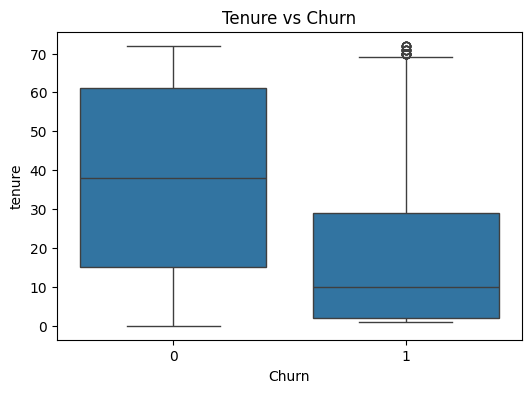

In [48]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

This insight shows that "Customers with shorter tenure are significantly more likely to churn."

**Churn vs Monthly Charges**

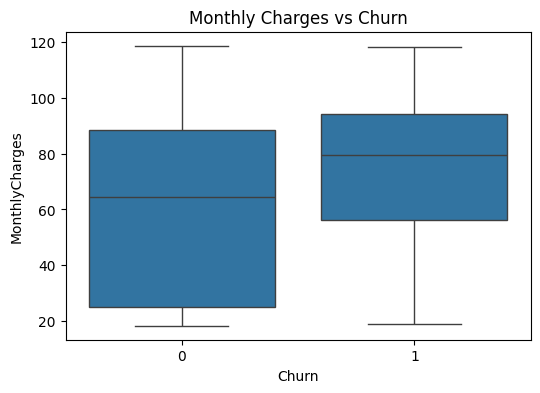

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Internet Service Impact**

In [50]:
internet_cols = ['InternetService_Fiber optic', 'InternetService_No']

for col in internet_cols:
    churn = df.groupby(col)['Churn'].mean() * 100
    print(f"\nChurn rate by {col}:\n", churn)


Churn rate by InternetService_Fiber optic:
 InternetService_Fiber optic
0    14.492019
1    41.892765
Name: Churn, dtype: float64

Churn rate by InternetService_No:
 InternetService_No
0    31.828893
1     7.404980
Name: Churn, dtype: float64


**Payment Method Risk**

In [51]:
payment_cols = [
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check']

for col in payment_cols:
    churn = df.groupby(col)['Churn'].mean() * 100
    print(f"\nChurn rate by {col}:\n", churn)


Churn rate by PaymentMethod_Electronic check:
 PaymentMethod_Electronic check
0    17.058572
1    45.285412
Name: Churn, dtype: float64

Churn rate by PaymentMethod_Mailed check:
 PaymentMethod_Mailed check
0    28.742405
1    19.106700
Name: Churn, dtype: float64


This indicates that "Electronic check users usually have highest churn."

**Correlation with Churn (Top Drivers)**

In [52]:
corr = df.corr()['Churn'].sort_values(ascending=False)
corr.head(10)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
MonthlyCharges,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102
PhoneService,0.011942


#Churn Prediction Modeling

**Train-Test Split**

In [53]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
) #Stratification is very important

**Baseline Model**

We are using Logistic regression model here

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8426954971712005


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Random Forest**

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

ROC-AUC: 0.8424126172208013


**Feature Importance**

In [56]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
tenure,0.180674
TotalCharges,0.141881
MonthlyCharges,0.103665
Contract_Two year,0.094419
InternetService_Fiber optic,0.063212
PaymentMethod_Electronic check,0.049733
Contract_One year,0.039637
OnlineSecurity_Yes,0.032476
TechSupport_Yes,0.026710
PaperlessBilling,0.020741


# Customer lifetime value (CLV)


**Add Churn Probability to Dataset**

In [57]:
df_test = X_test.copy()
df_test['Actual_Churn'] = y_test.values
df_test['Churn_Probability'] = y_prob_rf

**Estimate Expected Lifetime**

In [58]:
df_test['Expected_Lifetime'] = (1 - df_test['Churn_Probability']) * df_test['tenure']

**Now Calculating CLV**

In [59]:
df_test['CLV'] = df_test['MonthlyCharges'] * df_test['Expected_Lifetime']

**Segment Customers**

In [60]:
df_test['CLV_Segment'] = pd.qcut(df_test['CLV'], 4, labels=['Low', 'Medium', 'High', 'Very High'])
df_test['Risk_Segment'] = pd.qcut(df_test['Churn_Probability'], 4, labels=['Low Risk', 'Moderate', 'High', 'Very High Risk'])

**Identify PRIORITY CUSTOMERS**

High CLV + High Risk

In [61]:
priority_customers = df_test[
    (df_test['CLV_Segment'].isin(['High','Very High'])) &
    (df_test['Risk_Segment'].isin(['High','Very High Risk']))
]
priority_customers.shape

(187, 36)

# ROI Simulation

**Retention Cost**

In [62]:
retention_cost = 500
total_campaign_cost = retention_cost * len(priority_customers)
total_campaign_cost

93500

**Revenue at Risk**


In [63]:
revenue_at_risk = priority_customers['CLV'].sum()
revenue_at_risk

np.float64(418107.5722473352)

**Expected Revenue Saved**


In [64]:
expected_revenue_saved = revenue_at_risk * 0.25
expected_revenue_saved

np.float64(104526.8930618338)

**Net ROI**

In [66]:
roi = expected_revenue_saved - total_campaign_cost
roi

np.float64(11026.893061833805)